## Bộ dữ liệu được sử dụng trong nghiên cứu này là Pima Indians Diabetes Dataset, chứa các thông tin lâm sàng của phụ nữ gốc Pima (Mỹ) với 8 đặc trưng chính liên quan đến sức khỏe như:

- Pregnancies – số lần mang thai

- Glucose – nồng độ glucose trong máu

- BloodPressure – huyết áp tâm trương

- SkinThickness – độ dày lớp da (mm)

- Insulin – nồng độ insulin huyết thanh

- BMI – chỉ số khối cơ thể

- DiabetesPedigreeFunction – chỉ số di truyền về nguy cơ tiểu đường

- Age – tuổi của bệnh nhân

- Cột Outcome (0 = không bị tiểu đường, 1 = bị tiểu đường) là nhãn mục tiêu.
Mục tiêu của bài toán là xây dựng mô hình dự đoán khả năng mắc bệnh đái tháo đường dựa trên các đặc trưng nêu trên.

### Làm sạch dữ liệu

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/kaggle/input/diabetescsv/diabetes.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
# Hiển thị 5 dòng đầu
print("\n5 dòng đầu tiên:")
print(df.head())


5 dòng đầu tiên:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


### Kiểm tra giá trị thiếu


In [4]:
print("Tổng số giá trị NaN trong mỗi cột:")
print(df.isnull().sum())

Tổng số giá trị NaN trong mỗi cột:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Kiểm tra giá trị độc nhất

In [5]:
print("Số lượng giá trị độc nhất trong mỗi cột:")
print(df.nunique())

Số lượng giá trị độc nhất trong mỗi cột:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


In [6]:
df['Insulin'] = df['Insulin'].astype('float64')  # Chuyển Insulin sang float64
df['Outcome'] = df['Outcome'].astype('category')  # Chuyển Outcome sang category

### Kiểm tra và loại bỏ dữ liệu trùng lặp

In [7]:
# Kiểm tra số lượng dòng trùng lặp
duplicate_rows = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_rows}")

Số lượng dòng trùng lặp: 0


### Xác định và loại bỏ outlier

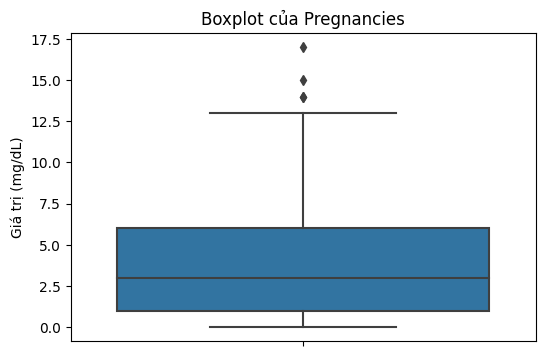

In [8]:
# Boxplot riêng cho từng biến
# 1. Pregnancies
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Pregnancies'])
plt.title("Boxplot của Pregnancies")
plt.ylabel("Giá trị (mg/dL)")
plt.show()

 *1. Pregnancies:
Outlier: Giá trị cao (>13, tối đa 17), nhưng hợp lý trong bối cảnh dân số Pima.
Lý do: Không bất thường, phản ánh đặc điểm sinh sản.*

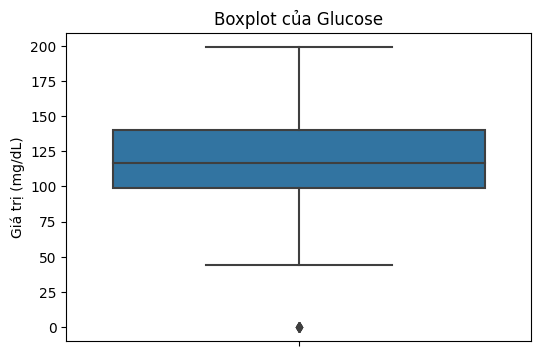

In [9]:
# Boxplot riêng cho từng biến
# 2. Glucose
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Glucose'])
plt.title("Boxplot của Glucose")
plt.ylabel("Giá trị (mg/dL)")
plt.show()

2. Glucose (Nồng độ glucose)

Outlier quan sát: 5 giá trị 0 (dưới râu, ~50 mg/dL).
Lý do không hợp lý: Nồng độ glucose trong máu không thể là 0 ở người sống, ngay cả khi đói (thường ≥70 mg/dL). Đây có thể là missing data hoặc lỗi nhập liệu.

Biện pháp xử lý:

Impute: Thay 0 bằng trung vịcủa cột.

In [10]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())

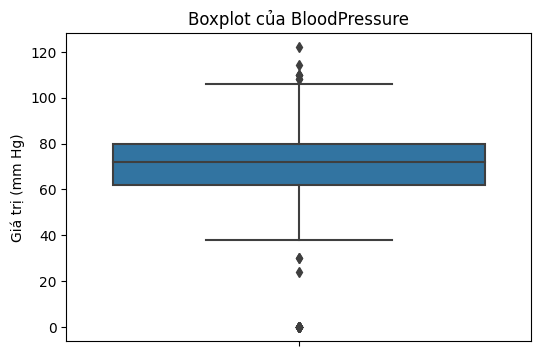

In [11]:
# 3. BloodPressure
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['BloodPressure'])
plt.title("Boxplot của BloodPressure")
plt.ylabel("Giá trị (mm Hg)")
plt.show()

3. BloodPressure (Huyết áp tâm trương)

Outlier quan sát: 35 giá trị 0 (dưới râu, ~30 mm Hg).
Lý do không hợp lý: Huyết áp tâm trương không thể là 0 (giá trị bình thường 60–90 mm Hg). Đây là lỗi đo.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~72 mm Hg).

In [12]:
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].median())

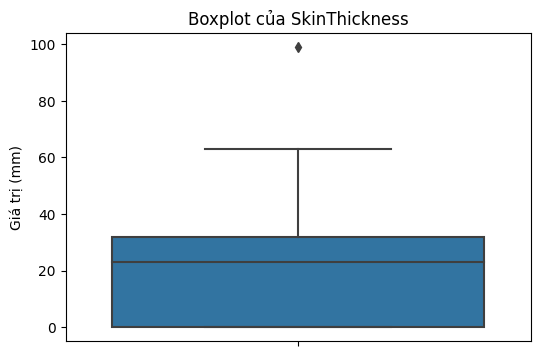

In [13]:
# 4. SkinThickness
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['SkinThickness'])
plt.title("Boxplot của SkinThickness")
plt.ylabel("Giá trị (mm)")
plt.show()

4. SkinThickness (Độ dày nếp da)

Outlier quan sát: 227 giá trị 0 (dưới râu, ~0 mm) và một số giá trị cao (>50 mm).
Lý do không hợp lý: 0 mm là không khả thi (độ dày nếp da tối thiểu ~7 mm ở người trưởng thành), có thể là missing data. Giá trị cao (>50 mm) hiếm nhưng có thể hợp lý ở người béo phì.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~23 mm).

In [14]:
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].median())

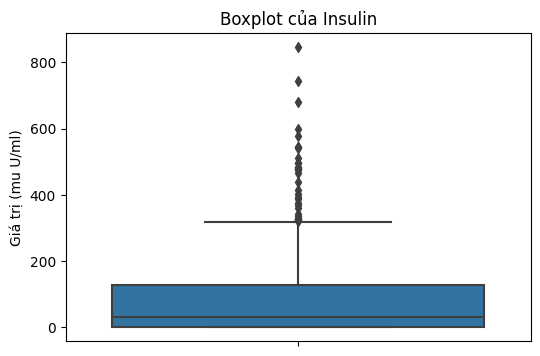

In [15]:
# 5. Insulin
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Insulin'])
plt.title("Boxplot của Insulin")
plt.ylabel("Giá trị (mu U/ml)")
plt.show()

5. Insulin (Mức insulin)

Outlier quan sát: 374 giá trị 0 (dưới râu, ~0 mu U/ml) và nhiều giá trị cao (>300 mu U/ml, lên đến 846).
Lý do không hợp lý: 0 mu U/ml là bất thường (mức insulin bình thường 2–30 mu U/ml khi đói, tăng sau OGTT), có thể là missing data. Giá trị cao (>600) hiếm nhưng có thể do đề kháng insulin cực độ hoặc lỗi đo.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~32 mu U/ml).



In [16]:
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())

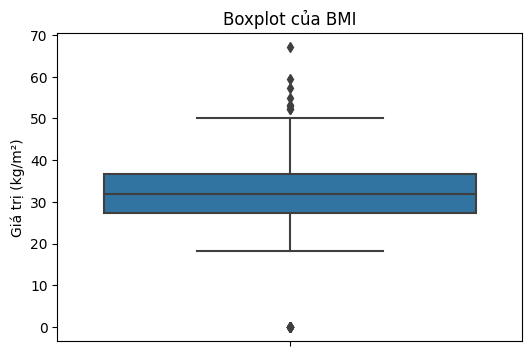

In [17]:
# 6. BMI
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['BMI'])
plt.title("Boxplot của BMI")
plt.ylabel("Giá trị (kg/m²)")
plt.show()

6. BMI (Chỉ số khối cơ thể)

Outlier quan sát: 11 giá trị 0 (dưới râu, ~15 kg/m²) và một số giá trị cao (>50 kg/m², lên đến 67.1).
Lý do không hợp lý: 0 kg/m² là không thể (BMI bình thường 18.5–24.9), có thể là missing data. Giá trị cao (>50) hiếm nhưng khả thi ở người béo phì morbid.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~32.0 kg/m²).


In [18]:
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())

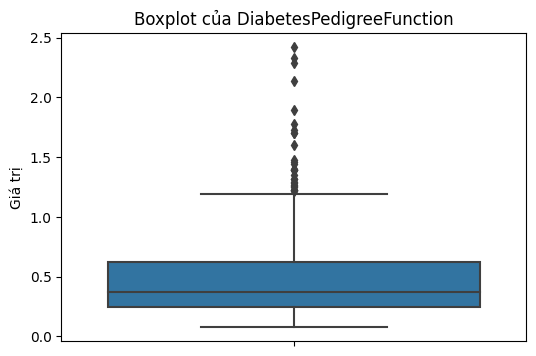

In [19]:
# 7. DiabetesPedigreeFunction
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['DiabetesPedigreeFunction'])
plt.title("Boxplot của DiabetesPedigreeFunction")
plt.ylabel("Giá trị")
plt.show()

7. DiabetesPedigreeFunction (Hàm phả hệ tiểu đường)

Outlier quan sát: Giá trị >1.5 (lên đến 2.42).
Lý do không hợp lý: Không có, vì DPF là giá trị liên tục phản ánh nguy cơ di truyền, và giá trị cao (>1.5) hợp lý ở quần thể Pima có tiền sử tiểu đường cao.
Biện pháp xử lý: Không cần xử lý, nhưng chuẩn hóa (StandardScaler) để giảm tác động outlier trong mô hình.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['DiabetesPedigreeFunction'] = scaler.fit_transform(df[['DiabetesPedigreeFunction']])



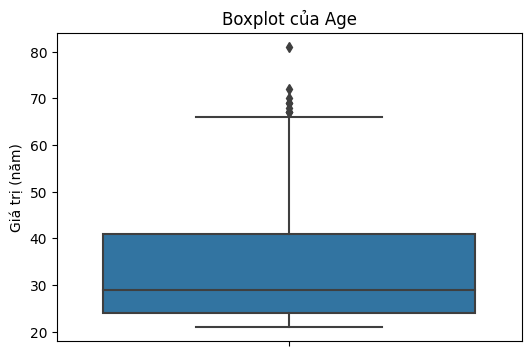

In [21]:
# 8. Age
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Age'])
plt.title("Boxplot của Age")
plt.ylabel("Giá trị (năm)")
plt.show()

8. Age (Tuổi)

Outlier quan sát: Giá trị >60 (lên đến 81).
Lý do không hợp lý: Không có, vì tuổi cao (>60) là yếu tố nguy cơ tự nhiên và hợp lý trong quần thể Pima.
Biện pháp xử lý: Không cần xử lý, giữ nguyên để phản ánh đặc điểm dân số.

## KẾT THÚC

In [2]:
!jupyter nbconvert --to html "processing.ipynb"

[NbConvertApp] Converting notebook processing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 459419 bytes to processing.html
